# Generalization Results

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

from analyze_results import plot_model_results, plot_model_comparison
import pandas as pd

------

## **Null Baseline**

**Split**: reuses paradigm 3's exact 5 folds/subjects unchanged. The only difference: every EEG trial is paired with the wrong stimulus (either a different repeat of the same song shifted ±0.5–2s, or a different song entirely — sampled per trial, verified by hard assert to never accidentally match the true alignment).

**Purpose**: this is the chance ceiling. If the model gets a meaningfully non-zero r here, it's fitting something other than genuine stimulus→response structure (e.g., subject-specific EEG autocorrelation, spectral artifacts) — i.e., the whole pipeline has a leak, independent of paradigm 1–4's results.

In [2]:
# for i in range(5):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     plot_model_results('conv_null_nonlinear', pickle_folder=f'generalization_results/null_baseline/fold{i}')

-----
## **Paradigm 1 - memorization case**

**Split**: single split (not k-fold). For each subject, 45% of (subject, song) pairs have their 3 repeats scattered one-each to train/val/test; the rest give all 3 repeats to train only. Result: 420 train / 90 val / 90 test trials (70/15/15%), all 20 subjects and all 10 songs appear in every split.

**Purpose**: train and test overlap in subject and song identity (just different repeats). It measures the model's raw fitting capacity, i.e. the ceiling other paradigms are compared against. 

In [3]:
# plot_model_results('conv_linear', pickle_folder=f'generalization_results/paradigm1_memorization_ceiling')

----
## **Paradigm 2 - within subjects across stimulus**

**Split**: 10 folds (one per held-out song). Fold k: train on 8 songs, val on 1 different song, test on 1 held-out song — all 20 subjects participate in every fold, in every role. 480/60/60 trials/fold.

**Purpose**: "Can the model generalize to novel music for brains it has already trained on?" Tests generalization across stimulus only.

### Comparing Linear vs Non Linear 

In [4]:
# paradigm2_stats = []
# for i in range(9):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     stats_df = plot_model_comparison(['conv_linear', 'conv_nonlinear'], pickle_folder=f'generalization_results/paradigm2_within_subject_across_stimulus/fold{i}')
#     paradigm2_stats.append({f'fold{i}':stats_df})

### Individual Model Performance

In [5]:
# for i in range(9):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     plot_model_results('conv_linear', pickle_folder=f'generalization_results/paradigm2_within_subject_across_stimulus/fold{i}')

In [6]:
# for i in range(9):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     plot_model_results('conv_nonlinear', pickle_folder=f'generalization_results/paradigm2_within_subject_across_stimulus/fold{i}')

-----
## **Paradigm 3 - across subjects within stimulus**

**Split**: 5 folds via GroupKFold(groups=subject) run separately within musician/non-musician strata (so every fold's val and test sets are each exactly [1 musician, 1 non-musician]) — musician balance a plain unstratified GroupKFold couldn't guarantee. Train = 16 subjects, val = 2 held-out subjects, test = 2 different held-out subjects, all using all 10 songs. 480/60/60 trials/fold. Across the 5 folds every subject is held out exactly once.

**Purpose**: "Can the model adapt to new brains listening to already-heard content?" Tests generalization across subject only.

In [7]:
from analyze_results import plot_model_comparison, plot_model_results

### Comparing Linear vs Non Linear 

In [8]:
# paradigm3_stats = []
# for i in range(5):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     stats_df = plot_model_comparison(['conv_linear', 'conv_nonlinear'], pickle_folder=f'generalization_results/paradigm3_across_subject_within_stimulus/fold{i}')
#     paradigm3_stats.append({f'fold{i}':stats_df})

### Individual Model Performance

In [9]:
# for i in range(5):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     plot_model_results('conv_linear', pickle_folder=f'generalization_results/paradigm3_across_subject_within_stimulus/fold{i}')

In [10]:
# for i in range(5):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     plot_model_results('conv_nonlinear', pickle_folder=f'generalization_results/paradigm3_across_subject_within_stimulus/fold{i}')

----
## **Paradigm 4 - across subject across stimulus**

**Split**: 5 folds zipping a paradigm-3-style subject fold (4 held-out subjects: 2 musicians + 2 non-musicians) with a deterministic song fold (2 songs held out, disjoint from the val song). Train = 16 subjects × 7 songs; val = same 16 subjects × 1 different held-out song; test = 4 entirely unseen subjects × 2 entirely unseen songs. 336/48/24 trials/fold (408 total, not 600 — the leftover songs/subjects don't fit any of the three cells and are deliberately dropped).

**Purpose**: test subjects and test songs are both completely absent from training — this is the real test of whether the model learned a general acoustic→neural mapping rather than something tied to a specific song or brain.

In [11]:
# paradigm4_stats = []
# for i in range(5):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     stats_df = plot_model_comparison(['conv_linear', 'conv_nonlinear'], pickle_folder=f'generalization_results/paradigm4_across_subject_across_stimulus/fold{i}')
#     paradigm4_stats.append(stats_df)

In [12]:
# for i in range(5):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     plot_model_results('conv_linear', pickle_folder=f'generalization_results/paradigm4_across_subject_across_stimulus/fold{i}')

In [13]:
# for i in range(5):
#     print("="*64)
#     print(f"Fold {i} Results")
#     print("="*64)
#     plot_model_results('conv_nonlinear', pickle_folder=f'generalization_results/paradigm4_across_subject_across_stimulus/fold{i}')

-----
## **Summary of Results**

%matplotlib inline

In [14]:
from generalization_holdout.analyze_holdout_results import combine_holdout_results
import generalization_holdout.results_io

combined_holdout_df = combine_holdout_results(results_dir='results/generalization_results')

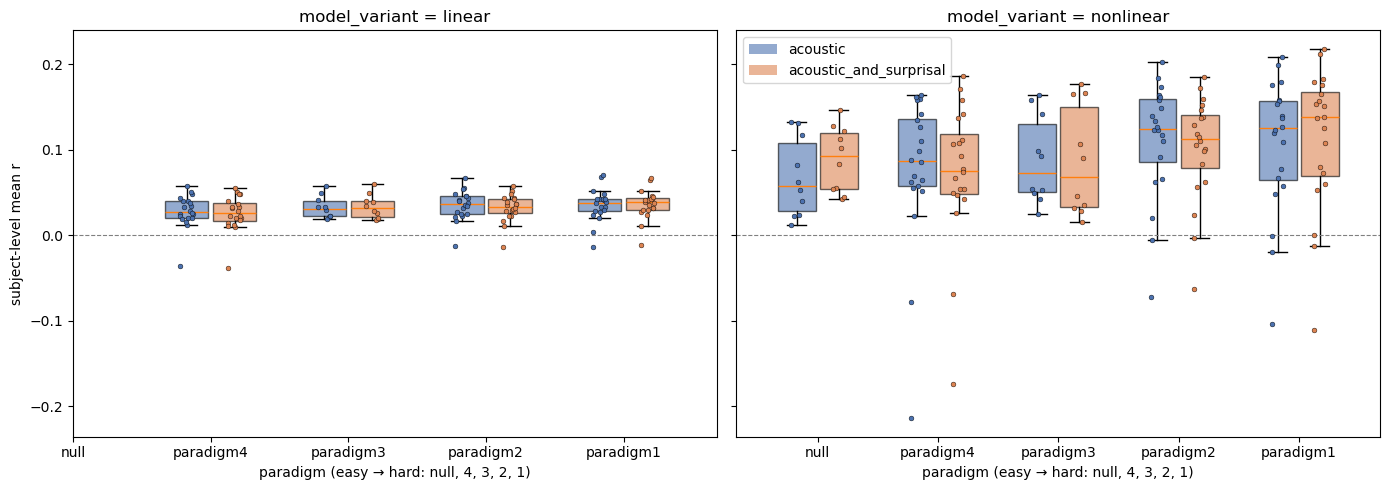

Null vs paradigm4 (nonlinear): generalizes above chance to unseen
subjects AND unseen songs?
[acoustic] n_subjects=10  null=0.0678  paradigm4(matched n=10)=0.1194  paradigm4(full n=20)=0.0760  diff=0.0516  p=0.0034
[acoustic_and_surprisal] n_subjects=10  null=0.0888  paradigm4(matched n=10)=0.1145  paradigm4(full n=20)=0.0731  diff=0.0257  p=0.0698

Paradigm4 vs paradigm1: overfitting / memorization gap
[   linear | acoustic              ] n_subjects=20  paradigm1=0.0355  paradigm4=0.0280  gap=0.0075  ratio(p1/p4)=1.27x
[   linear | acoustic_and_surprisal] n_subjects=20  paradigm1=0.0362  paradigm4=0.0258  gap=0.0104  ratio(p1/p4)=1.40x
[nonlinear | acoustic              ] n_subjects=20  paradigm1=0.1055  paradigm4=0.0760  gap=0.0295  ratio(p1/p4)=1.39x
[nonlinear | acoustic_and_surprisal] n_subjects=20  paradigm1=0.1121  paradigm4=0.0731  gap=0.0390  ratio(p1/p4)=1.53x

Musician vs non-musician breakdown


mean  \
paradigm                                 model_variant feature_set            subject_type           
null_baseline                            nonlinear     acoustic               Musician      0.0704   
                                                                              Non-musician  0.0652   
                                                       acoustic_and_surprisal Musician      0.0849   
                                                                              Non-musician  0.0928   
paradigm4_across_subject_across_stimulus linear        acoustic               Musician      0.0339   
                                                                              Non-musician  0.0221   
                                                       acoustic_and_surprisal Musician      0.0310   
                                                                              Non-musician  0.0205   
                                         nonlinear     acoustic               Musician      0.0861   
                                                                              Non-musician  0.0659   
                                                       acoustic_and_surprisal Musician      0.0811   
                                                                              Non-musician  0.0651   
paradigm3_across_subject_within_stimulus linear        acoustic               Musician      0.0406   
                                                                              Non-musician  0.0251   
                                                       acoustic_and_surprisal Musician      0.0418   
                                                                              Non-musician  0.0249   
                                         nonlinear     acoustic               Musician      0.1034   
                                                                              Non-musician  0.0720   
                                                       acoustic_and_surprisal Musician      0.1020   
                                                                              Non-musician  0.0703   
paradigm2_within_subject_across_stimulus linear        acoustic               Musician      0.0389   
                                                                              Non-musician  0.0315   
                                                       acoustic_and_surprisal Musician      0.0351   
                                                                              Non-musician  0.0291   
                                         nonlinear     acoustic               Musician      0.1071   
                                                                              Non-musician  0.1154   
                                                       acoustic_and_surprisal Musician      0.0979   
                                                                              Non-musician  0.1048   
paradigm1_memorization_ceiling           linear        acoustic               Musician      0.0363   
                                                                              Non-musician  0.0346   
                                                       acoustic_and_surprisal Musician      0.0370   
                                                                              Non-musician  0.0354   
                                         nonlinear     acoustic               Musician      0.0952   
                                                                              Non-musician  0.1158   
                                                       acoustic_and_surprisal Musician      0.0996   
                                                                              Non-musician  0.1246   

                                                                                               std  \
paradigm                                 model_variant feature_set            subject_type           
null_baseline


Musician vs non-musician t-test per paradigm/model_variant/feature_set
(paradigms 3/4/null are balanced by design on subject_type)
      null | nonlinear | acoustic               musician n=5 mean=0.0704 vs non-musician n=5 mean=0.0652 t=0.17 p=0.8713
      null | nonlinear | acoustic_and_surprisal musician n=5 mean=0.0849 vs non-musician n=5 mean=0.0928 t=-0.31 p=0.7651
 paradigm3 |    linear | acoustic               musician n=5 mean=0.0406 vs non-musician n=5 mean=0.0251 t=2.28 p=0.0517
 paradigm3 |    linear | acoustic_and_surprisal musician n=5 mean=0.0418 vs non-musician n=5 mean=0.0249 t=2.35 p=0.0468
 paradigm3 | nonlinear | acoustic               musician n=5 mean=0.1034 vs non-musician n=5 mean=0.0720 t=0.97 p=0.3610
 paradigm3 | nonlinear | acoustic_and_surprisal musician n=5 mean=0.1020 vs non-musician n=5 mean=0.0703 t=0.77 p=0.4643
 paradigm4 |    linear | acoustic               musician n=10 mean=0.0339 vs non-musician n=10 mean=0.0221 t=1.39 p=0.1825
 paradigm4 |    li

In [15]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sstats

from generalization_holdout.analyze_holdout_results import permutation_test

PARADIGM_ORDER = [
    'null_baseline',
    'paradigm4_across_subject_across_stimulus',
    'paradigm3_across_subject_within_stimulus',
    'paradigm2_within_subject_across_stimulus',
    'paradigm1_memorization_ceiling',
]
PARADIGM_LABELS = {
    'null_baseline': 'null',
    'paradigm4_across_subject_across_stimulus': 'paradigm4',
    'paradigm3_across_subject_within_stimulus': 'paradigm3',
    'paradigm2_within_subject_across_stimulus': 'paradigm2',
    'paradigm1_memorization_ceiling': 'paradigm1',
}
FEATURE_SETS = ['acoustic', 'acoustic_and_surprisal']
MODEL_VARIANTS = ['linear', 'nonlinear']

# ── channel -> subject (within fold) -> subject (pooled across folds) ──
# Channels within a subject are correlated, so channel-level n would overstate
# power; the subject is the unit of replication. Folds are pooled per subject
# so paradigm 2 (same subject retested in every song-rotation fold) collapses
# to one number per subject instead of one per (subject, fold); paradigms with
# subject-disjoint folds (null/3/4) pass straight through since each subject
# only ever appears in one fold.
subj_fold_r = (
    combined_holdout_df
    .groupby(['paradigm', 'fold', 'model_tag', 'feature_set', 'subject', 'subject_type'], observed=True)['r']
    .mean()
    .reset_index()
)
subj_r = (
    subj_fold_r
    .groupby(['paradigm', 'model_tag', 'feature_set', 'subject', 'subject_type'], observed=True)['r']
    .mean()
    .reset_index()
)
subj_r['model_variant'] = (
    subj_r['model_tag'].str.replace('conv_null_', '', regex=False).str.replace('conv_', '', regex=False)
)
subj_r['paradigm'] = pd.Categorical(subj_r['paradigm'], categories=PARADIGM_ORDER, ordered=True)


def subj_series(paradigm, variant, feature_set):
    sub = subj_r[(subj_r['paradigm'] == paradigm) & (subj_r['model_variant'] == variant)
                 & (subj_r['feature_set'] == feature_set)]
    return sub.set_index('subject')['r']


# ── 1. one axis, all 5 paradigms, easy -> hard, split by feature_set, faceted by model_variant ──
colors = {'acoustic': '#4C72B0', 'acoustic_and_surprisal': '#DD8452'}
fig, axes = plt.subplots(1, len(MODEL_VARIANTS), figsize=(14, 5), sharey=True)
width = 0.35
for ax, variant in zip(axes, MODEL_VARIANTS):
    vdf = subj_r[subj_r['model_variant'] == variant]
    for i, paradigm in enumerate(PARADIGM_ORDER):
        for j, fs in enumerate(FEATURE_SETS):
            data = vdf[(vdf['paradigm'] == paradigm) & (vdf['feature_set'] == fs)]['r'].dropna().values
            if len(data) == 0:
                continue
            pos = i + (j - 0.5) * width
            bp = ax.boxplot(data, positions=[pos], widths=width * 0.9, patch_artist=True, showfliers=False)
            for box in bp['boxes']:
                box.set_facecolor(colors[fs])
                box.set_alpha(0.6)
            jitter = np.random.default_rng(0).uniform(-0.05, 0.05, len(data))
            ax.scatter(np.full(len(data), pos) + jitter, data, s=12, color=colors[fs],
                       edgecolor='k', linewidth=0.3, zorder=3)
    ax.set_xticks(range(len(PARADIGM_ORDER)))
    ax.set_xticklabels([PARADIGM_LABELS[p] for p in PARADIGM_ORDER])
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(f"model_variant = {variant}")
    ax.set_xlabel("paradigm (easy → hard: null, 4, 3, 2, 1)")
axes[0].set_ylabel("subject-level mean r")
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[fs], alpha=0.6, label=fs) for fs in FEATURE_SETS]
axes[-1].legend(handles=handles, loc='upper left')
plt.tight_layout()
plt.show()

# note: null_baseline only has a 'nonlinear' model_variant (run_common.py's
# null_baseline_mismatched_stimulus.py defaults --variants to 'nonlinear' only),
# so the 'linear' facet has no null box -- the ridge-vs-conv blocker in
# TRF_conv_DIAGNOSTICS.md is specifically about the (as-yet unvalidated) linear
# conv variant, so a linear null-chance reference isn't available yet.

# ── 2. null vs paradigm4: the load-bearing "generalizes above chance to
#    unseen subjects AND unseen songs" claim. Paired by subject (inner-joined
#    on the subjects common to both -- null_baseline reuses paradigm 3's
#    "test"-role subjects specifically (10 of the 20), a strict subset of
#    paradigm 4's 20 test subjects), nonlinear only since that's all the null
#    baseline has.
#
#    IMPORTANT: "paradigm4=..." below is therefore paradigm4's mean over only
#    those 10 matched subjects, NOT its full 20-subject mean (reported
#    separately in section 3 below and in subj_r directly) -- printing both
#    numbers on each line so the two don't get confused with each other. ──
print("=" * 70)
print("Null vs paradigm4 (nonlinear): generalizes above chance to unseen")
print("subjects AND unseen songs?")
print("=" * 70)
for fs in FEATURE_SETS:
    null_s = subj_series('null_baseline', 'nonlinear', fs)
    p4_s = subj_series('paradigm4_across_subject_across_stimulus', 'nonlinear', fs)
    common = sorted(set(null_s.index) & set(p4_s.index))
    a, b = null_s.loc[common].values, p4_s.loc[common].values
    observed, p_val = permutation_test(a, b)
    print(f"[{fs}] n_subjects={len(common)}  null={a.mean():.4f}  "
          f"paradigm4(matched n={len(common)})={b.mean():.4f}  "
          f"paradigm4(full n={len(p4_s)})={p4_s.mean():.4f}  "
          f"diff={observed:.4f}  p={p_val:.4f}")

# ── 3. paradigm4 vs paradigm1: the overfitting/memorization gap this whole
#    folder was built to quantify. Paired by subject -- paradigm1 covers all
#    20 subjects, so "paradigm4=..." here IS the full 20-subject mean (matches
#    the "full n=20" number printed in section 2 above). ──
print()
print("=" * 70)
print("Paradigm4 vs paradigm1: overfitting / memorization gap")
print("=" * 70)
for variant in MODEL_VARIANTS:
    for fs in FEATURE_SETS:
        p1_s = subj_series('paradigm1_memorization_ceiling', variant, fs)
        p4_s = subj_series('paradigm4_across_subject_across_stimulus', variant, fs)
        common = sorted(set(p1_s.index) & set(p4_s.index))
        a, b = p1_s.loc[common].values, p4_s.loc[common].values
        gap = a.mean() - b.mean()
        ratio = a.mean() / b.mean() if b.mean() else np.nan
        print(f"[{variant:>9} | {fs:<22}] n_subjects={len(common)}  paradigm1={a.mean():.4f}  "
              f"paradigm4={b.mean():.4f}  gap={gap:.4f}  ratio(p1/p4)={ratio:.2f}x")

# ── 4. musician / non-musician breakdown (paradigms 3/4/null are balanced on
#    this by design) -- reported, not folded away, plus a quick per-cell
#    musician-vs-non-musician check for an interaction. ──
print()
print("=" * 70)
print("Musician vs non-musician breakdown")
print("=" * 70)
breakdown = (subj_r.groupby(['paradigm', 'model_variant', 'feature_set', 'subject_type'], observed=True)['r']
             .agg(['mean', 'std', 'count']).round(4))
display(breakdown)

print()
print("Musician vs non-musician t-test per paradigm/model_variant/feature_set")
print("(paradigms 3/4/null are balanced by design on subject_type)")
for paradigm in ['null_baseline', 'paradigm3_across_subject_within_stimulus', 'paradigm4_across_subject_across_stimulus']:
    for variant in MODEL_VARIANTS:
        for fs in FEATURE_SETS:
            sub = subj_r[(subj_r['paradigm'] == paradigm) & (subj_r['model_variant'] == variant) & (subj_r['feature_set'] == fs)]
            mus = sub[sub['subject_type'] == 'Musician']['r'].values
            non = sub[sub['subject_type'] == 'Non-musician']['r'].values
            if len(mus) < 2 or len(non) < 2:
                continue
            t, p = sstats.ttest_ind(mus, non)
            print(f"{PARADIGM_LABELS[paradigm]:>10} | {variant:>9} | {fs:<22} "
                  f"musician n={len(mus)} mean={mus.mean():.4f} vs non-musician n={len(non)} mean={non.mean():.4f} "
                  f"t={t:.2f} p={p:.4f}")

In [16]:
# ── Bootstrap CIs + paired effect sizes on the two comparisons above ──
# permutation_test gives a mean diff + p-value but no uncertainty interval and
# no effect-size magnitude -- with n=10-20 subjects a point estimate alone
# doesn't tell us how tight or loose that diff actually is, which is exactly
# what's needed to reason about the spread the user is asking about.

def bootstrap_ci_diff(x, y, n_boot=10000, ci=0.95, seed=0):
    """95% bootstrap CI for mean(x) - mean(y), resampling subject positions
    jointly (x and y must already be aligned to the same subject order)."""
    rng = np.random.default_rng(seed)
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    diffs = x[idx].mean(axis=1) - y[idx].mean(axis=1)
    lo, hi = np.percentile(diffs, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return lo, hi


def cohens_d_paired(x, y):
    """Paired Cohen's d_z = mean(x - y) / std(x - y, ddof=1)."""
    diff = x - y
    sd = diff.std(ddof=1)
    return diff.mean() / sd if sd > 0 else np.nan


print("=" * 70)
print("Null vs paradigm4 (nonlinear), with 95% bootstrap CI + effect size")
print("=" * 70)
# NOTE: like cell 26's section 2, "diff" and the implicit paradigm4 mean here
# are over only the 10 subjects null_baseline also evaluated -- NOT the same
# subject set as the paradigm4-vs-paradigm1 block below (n=20). See cell 26's
# section 2 for why (null_baseline only covers paradigm 3's 10 "test"-role
# subjects, a strict subset of paradigm 4's 20).
for fs in FEATURE_SETS:
    null_s = subj_series('null_baseline', 'nonlinear', fs)
    p4_s = subj_series('paradigm4_across_subject_across_stimulus', 'nonlinear', fs)
    common = sorted(set(null_s.index) & set(p4_s.index))
    null_vals, p4_vals = null_s.loc[common].values, p4_s.loc[common].values
    observed, p_val = permutation_test(null_vals, p4_vals)
    # sign convention matches cell 26's "diff" above: paradigm4 - null
    lo, hi = bootstrap_ci_diff(p4_vals, null_vals)
    d_z = cohens_d_paired(p4_vals, null_vals)
    print(f"[{fs}] n_subjects={len(common)} (matched to null)  diff={observed:.4f}  "
          f"95% CI=[{lo:.4f}, {hi:.4f}]  d_z={d_z:.2f}  p={p_val:.4f}")

print()
print("=" * 70)
print("Paradigm4 vs paradigm1, with 95% bootstrap CI + effect size on the gap")
print("=" * 70)
for variant in MODEL_VARIANTS:
    for fs in FEATURE_SETS:
        p1_s = subj_series('paradigm1_memorization_ceiling', variant, fs)
        p4_s = subj_series('paradigm4_across_subject_across_stimulus', variant, fs)
        common = sorted(set(p1_s.index) & set(p4_s.index))
        p1_vals, p4_vals = p1_s.loc[common].values, p4_s.loc[common].values
        gap = p1_vals.mean() - p4_vals.mean()
        # sign convention matches cell 26's "gap" above: paradigm1 - paradigm4
        lo, hi = bootstrap_ci_diff(p1_vals, p4_vals)
        d_z = cohens_d_paired(p1_vals, p4_vals)
        print(f"[{variant:>9} | {fs:<22}] n_subjects={len(common)}  gap={gap:.4f}  "
              f"95% CI=[{lo:.4f}, {hi:.4f}]  d_z={d_z:.2f}")


Null vs paradigm4 (nonlinear), with 95% bootstrap CI + effect size
[acoustic] n_subjects=10 (matched to null)  diff=0.0516  95% CI=[0.0268, 0.0785]  d_z=1.15  p=0.0034


[acoustic_and_surprisal] n_subjects=10 (matched to null)  diff=0.0257  95% CI=[0.0038, 0.0520]  d_z=0.62  p=0.0698

Paradigm4 vs paradigm1, with 95% bootstrap CI + effect size on the gap
[   linear | acoustic              ] n_subjects=20  gap=0.0075  95% CI=[0.0014, 0.0131]  d_z=0.54
[   linear | acoustic_and_surprisal] n_subjects=20  gap=0.0104  95% CI=[0.0050, 0.0155]  d_z=0.85
[nonlinear | acoustic              ] n_subjects=20  gap=0.0295  95% CI=[0.0037, 0.0536]  d_z=0.50
[nonlinear | acoustic_and_surprisal] n_subjects=20  gap=0.0390  95% CI=[0.0106, 0.0646]  d_z=0.62


In [17]:
# ── Variance-components decomposition: how much of the spread in r is
#    subject-driven vs channel-driven vs fold/song-driven vs pure residual? ──
#
# combined_holdout_df is channel-level (one row per subject x channel x
# fold), so unlike subj_r above it still has the resolution needed to
# attribute variance to subject identity, channel identity, and fold/song
# identity separately. subject and channel are crossed, not nested (every
# subject shares the same 64-channel montage), and statsmodels' MixedLM
# doesn't support genuinely crossed random effects directly -- the standard
# workaround is a single dummy top-level `groups` column with each crossed
# factor folded into `vc_formula` instead (documented statsmodels pattern for
# crossed random effects, e.g. the Pastes/Batch-Cask example in their docs).
#
# Note: when a variance component's true value is near zero (as expected for
# e.g. null_baseline, where there's no real subject/channel structure to
# fit), REML optimization can land on a boundary solution -- this triggers
# noisy-but-benign RuntimeWarning/ConvergenceWarning spam from the optimizer
# probing invalid covariance matrices along the way, which we suppress here;
# `result.converged` is still captured per combo so boundary/non-converged
# fits are flagged in the output table rather than silently trusted.

import warnings
import statsmodels.formula.api as smf


def variance_components(df_subset):
    """Fit r ~ 1 with subject, channel, and (if >1 fold present) fold as
    crossed variance components. Returns a dict of variances (raw + percent
    of total) plus a `converged` flag."""
    data = df_subset.copy()
    data['_grp'] = 'all'
    vc_terms = {'subject': '0 + C(subject)', 'channel': '0 + C(channel)'}
    if data['fold'].nunique() > 1:
        vc_terms['fold'] = '0 + C(fold)'

    model = smf.mixedlm('r ~ 1', data, groups=data['_grp'], vc_formula=vc_terms)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        result = model.fit(reml=True)

    # statsmodels does not preserve vc_formula's dict order in result.vcomp --
    # model.exog_vc.names is the authoritative order to zip against.
    vc_names = list(getattr(model.exog_vc, 'names', vc_terms.keys()))
    assert len(vc_names) == len(result.vcomp), \
        f"variance_components: {len(vc_names)} vc names vs {len(result.vcomp)} vcomp estimates"
    variances = dict(zip(vc_names, result.vcomp))
    variances['residual'] = result.scale
    total = sum(variances.values())

    out = {f'{name}_var': val for name, val in variances.items()}
    out.update({f'pct_{name}': (val / total * 100 if total > 0 else np.nan)
                for name, val in variances.items()})
    out['n_rows'] = len(data)
    out['has_fold_component'] = 'fold' in vc_terms
    out['converged'] = result.converged
    return out


def model_tag_for(paradigm, variant):
    if paradigm == 'null_baseline':
        return 'conv_null_nonlinear' if variant == 'nonlinear' else None
    return f'conv_{variant}'


vc_rows = []
for paradigm in PARADIGM_ORDER:
    for variant in MODEL_VARIANTS:
        tag = model_tag_for(paradigm, variant)
        if tag is None:
            continue
        for fs in FEATURE_SETS:
            subset = combined_holdout_df[
                (combined_holdout_df['paradigm'] == paradigm)
                & (combined_holdout_df['model_tag'] == tag)
                & (combined_holdout_df['feature_set'] == fs)
            ]
            if subset.empty:
                continue
            try:
                vc = variance_components(subset)
            except Exception as e:
                print(f"[variance_components] skipped {paradigm}/{variant}/{fs}: {e}")
                continue
            vc_rows.append({'paradigm': PARADIGM_LABELS[paradigm], 'model_variant': variant,
                             'feature_set': fs, **vc})

vc_df = pd.DataFrame(vc_rows)
pct_cols = [c for c in vc_df.columns if c.startswith('pct_')]
display(vc_df[['paradigm', 'model_variant', 'feature_set', 'n_rows', 'converged'] + pct_cols].round(1))

not_converged = vc_df[~vc_df['converged']]
if len(not_converged):
    print(f"\n[warn] {len(not_converged)}/{len(vc_df)} fits did not fully converge (likely a "
          f"variance component at/near the zero boundary -- interpret those rows' percentages "
          f"as approximate):")
    for _, row in not_converged.iterrows():
        print(f"  {row['paradigm']} | {row['model_variant']} | {row['feature_set']}")


,paradigm,model_variant,feature_set,n_rows,converged,pct_channel,pct_fold,pct_subject,pct_residual
0,null,nonlinear,acoustic,1280,True,8.7,0.7,1.6,89.0
1,null,nonlinear,acoustic_and_surprisal,1280,False,8.4,1.8,1.4,88.3
2,paradigm4,linear,acoustic,1280,True,9.5,8.6,19.3,62.7
3,paradigm4,linear,acoustic_and_surprisal,1280,True,8.3,6.9,24.3,60.5
4,paradigm4,nonlinear,acoustic,1280,False,4.6,0.0,4.6,90.8
5,paradigm4,nonlinear,acoustic_and_surprisal,1280,True,4.1,0.0,4.1,91.8
6,paradigm3,linear,acoustic,640,True,13.6,0.0,17.0,69.4
7,paradigm3,linear,acoustic_and_surprisal,640,True,13.8,0.0,18.6,67.6
8,paradigm3,nonlinear,acoustic,640,False,4.4,1.3,0.0,94.2
9,paradigm3,nonlinear,acoustic_and_surprisal,640,True,4.0,1.2,1.5,93.3



[warn] 4/18 fits did not fully converge (likely a variance component at/near the zero boundary -- interpret those rows' percentages as approximate):
  null | nonlinear | acoustic_and_surprisal
  paradigm4 | nonlinear | acoustic
  paradigm3 | nonlinear | acoustic
  paradigm1 | nonlinear | acoustic_and_surprisal


In [18]:
# ── ICC: is a subject's r a stable trait across channels, or just noise? ──
#
# ICC(C,k) (fixed set of "raters", consistency form, averaged over all k
# raters) is the right ICC variant here: the same 64 channels are used for
# every subject (not a random sample of raters drawn per subject, which
# would call for the "A"/agreement form), and we want the reliability of the
# *mean over all 64 channels* (the "k" form), which is exactly what subj_r's
# per-subject r already is. High ICC(C,k) means a subject's goodness/badness
# is consistent across channels -- a real, stable per-subject effect. Low
# ICC(C,k) means the per-channel r is mostly noise and the good/bad subject
# ranking in subj_r shouldn't be trusted at face value.
#
# Note: pingouin 0.6.1's intraclass_corr labels this row 'ICC(C,k)' (Shrout &
# Fleiss notation) with a 'CI95' column -- not the older 'ICC3k'/'CI95%'
# naming from earlier pingouin versions. Check `pg.intraclass_corr(...)`'s
# 'Type' column directly if this breaks again on a different pingouin version.

import pingouin as pg

ICC_TYPE = 'ICC(C,k)'


def icc_subject_reliability(df_subset):
    """ICC(C,k) for subject-level consistency across channels. `df_subset`
    must already be pooled to one row per (subject, channel) -- fold-average
    first for paradigms where a subject appears in multiple folds (e.g.
    paradigm2), matching subj_r's own fold-pooling above."""
    pooled = df_subset.groupby(['subject', 'channel'], observed=True)['r'].mean().reset_index()
    icc_df = pg.intraclass_corr(data=pooled, targets='subject', raters='channel', ratings='r')
    row = icc_df[icc_df['Type'] == ICC_TYPE].iloc[0]
    return row['ICC'], row['CI95'], row['pval']


icc_rows = []
for paradigm in PARADIGM_ORDER:
    for variant in MODEL_VARIANTS:
        tag = model_tag_for(paradigm, variant)
        if tag is None:
            continue
        for fs in FEATURE_SETS:
            subset = combined_holdout_df[
                (combined_holdout_df['paradigm'] == paradigm)
                & (combined_holdout_df['model_tag'] == tag)
                & (combined_holdout_df['feature_set'] == fs)
            ]
            if subset.empty:
                continue
            try:
                icc, ci95, pval = icc_subject_reliability(subset)
            except Exception as e:
                print(f"[ICC] skipped {paradigm}/{variant}/{fs}: {e}")
                continue
            icc_rows.append({'paradigm': PARADIGM_LABELS[paradigm], 'model_variant': variant,
                              'feature_set': fs, 'ICC(C,k)': icc, 'CI95': ci95, 'p': pval})

icc_df_summary = pd.DataFrame(icc_rows)
display(icc_df_summary.round(3))

print(f"\nInterpretation: {ICC_TYPE} close to 1 -> a subject's r is a stable trait across all 64")
print("channels (a real, reproducible per-subject effect, worth chasing down with covariates).")
print(f"{ICC_TYPE} close to 0 -> per-channel r is mostly noise; don't over-read the good/bad subject")
print("ranking in the boxplots/scatter above at face value.")


,paradigm,model_variant,feature_set,"ICC(C,k)",CI95,p
0,null,nonlinear,acoustic,0.571,"[0.08, 0.87]",0.014
1,null,nonlinear,acoustic_and_surprisal,0.223,"[-0.66, 0.77]",0.241
2,paradigm4,linear,acoustic,0.964,"[0.94, 0.98]",0.000
3,paradigm4,linear,acoustic_and_surprisal,0.970,"[0.95, 0.99]",0.000
4,paradigm4,nonlinear,acoustic,0.764,"[0.59, 0.89]",0.000
5,paradigm4,nonlinear,acoustic_and_surprisal,0.739,"[0.55, 0.88]",0.000
6,paradigm3,linear,acoustic,0.940,"[0.87, 0.98]",0.000
7,paradigm3,linear,acoustic_and_surprisal,0.946,"[0.88, 0.98]",0.000
8,paradigm3,nonlinear,acoustic,0.530,"[-0.0, 0.86]",0.026
9,paradigm3,nonlinear,acoustic_and_surprisal,0.641,"[0.23, 0.89]",0.003



Interpretation: ICC(C,k) close to 1 -> a subject's r is a stable trait across all 64
channels (a real, reproducible per-subject effect, worth chasing down with covariates).
ICC(C,k) close to 0 -> per-channel r is mostly noise; don't over-read the good/bad subject
ranking in the boxplots/scatter above at face value.


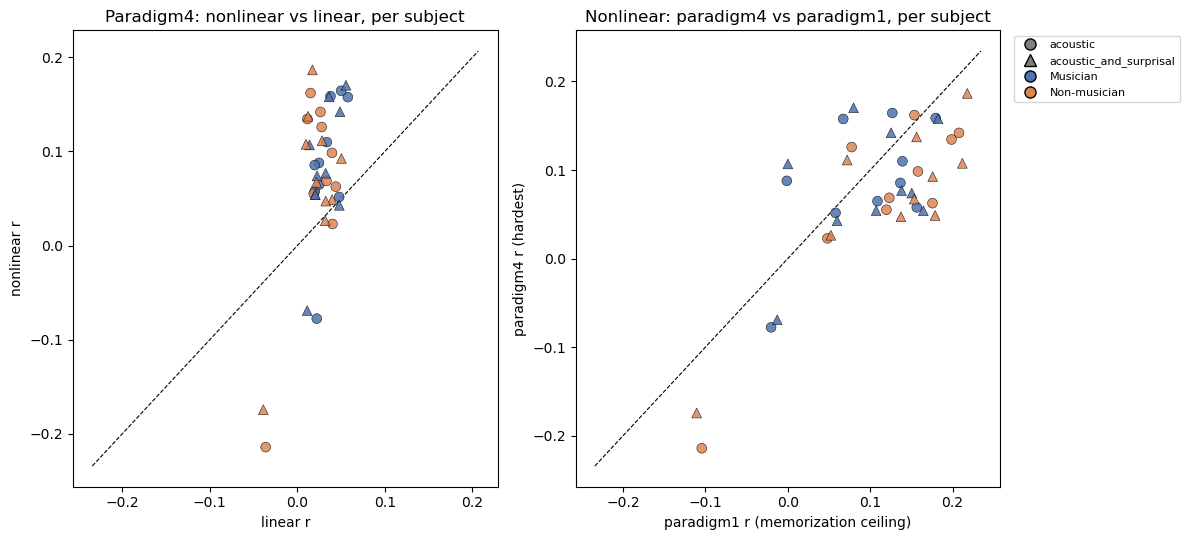

In [19]:
# ── Paired subject-level scatter: is "good subject / bad subject" a stable
#    identity, or does it scramble across models / paradigms? ──
from matplotlib.lines import Line2D

subject_type_lookup = subj_r.drop_duplicates('subject').set_index('subject')['subject_type']
type_colors = {'Musician': '#4C72B0', 'Non-musician': '#DD8452'}
fs_markers = {'acoustic': 'o', 'acoustic_and_surprisal': '^'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# A: nonlinear vs linear r, paradigm4, per subject -- same subject bad under
# both architectures implies a subject-level factor, not training instability
# specific to one architecture.
ax = axes[0]
for fs in FEATURE_SETS:
    lin = subj_series('paradigm4_across_subject_across_stimulus', 'linear', fs)
    non = subj_series('paradigm4_across_subject_across_stimulus', 'nonlinear', fs)
    common = sorted(set(lin.index) & set(non.index))
    colors_ = [type_colors[subject_type_lookup[s]] for s in common]
    ax.scatter(lin.loc[common], non.loc[common], c=colors_, marker=fs_markers[fs],
               edgecolor='k', linewidth=0.4, s=50, alpha=0.85)
lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, zorder=0)
ax.set_xlabel('linear r'); ax.set_ylabel('nonlinear r')
ax.set_title('Paradigm4: nonlinear vs linear, per subject')

# B: paradigm1 (ceiling) vs paradigm4 (hardest) r, nonlinear, per subject --
# weak paradigm4 performers who are ALSO weak at their own memorization
# ceiling point to a subject-level signal-quality story; good-ceiling-but-
# poor-generalization subjects point to overfitting specific to that subject.
ax = axes[1]
for fs in FEATURE_SETS:
    p1 = subj_series('paradigm1_memorization_ceiling', 'nonlinear', fs)
    p4 = subj_series('paradigm4_across_subject_across_stimulus', 'nonlinear', fs)
    common = sorted(set(p1.index) & set(p4.index))
    colors_ = [type_colors[subject_type_lookup[s]] for s in common]
    ax.scatter(p1.loc[common], p4.loc[common], c=colors_, marker=fs_markers[fs],
               edgecolor='k', linewidth=0.4, s=50, alpha=0.85)
lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, zorder=0)
ax.set_xlabel('paradigm1 r (memorization ceiling)'); ax.set_ylabel('paradigm4 r (hardest)')
ax.set_title('Nonlinear: paradigm4 vs paradigm1, per subject')

legend_elems = (
    [Line2D([0], [0], marker=fs_markers[fs], color='w', markerfacecolor='gray',
             markeredgecolor='k', label=fs, markersize=8) for fs in FEATURE_SETS]
    + [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markeredgecolor='k',
               label=st, markersize=8) for st, c in type_colors.items()]
)
axes[1].legend(handles=legend_elems, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()


### Paired Linear vs Non-linear comparison per subject

For each subject, within a fixed `(paradigm, feature_set)` — so linear and
nonlinear are always compared on the exact same fold/test split — pair their
`linear_r` against their `nonlinear_r`. Run across all four paradigms that have
both variants (`null_baseline` only has `nonlinear`, so it's excluded). Group-level
significance (paired t-test + sign-flip permutation test, since n is small) and a
95% bootstrap CI on the mean diff are computed once per `(paradigm, feature_set)`
group and attached to every subject row in that group. Each row also flags whether
the subject is one of the 10 `null_baseline` test subjects (Sub5-9, Sub16-20), so
that specific subset used in the null-vs-paradigm4 comparison above can be isolated
directly from this CSV. Results are saved to
`results/generalization_results/linear_vs_nonlinear_paired_by_subject.csv`.

In [20]:
from pathlib import Path

NULL_BASELINE_10 = set(subj_series('null_baseline', 'nonlinear', 'acoustic').index)
LINEAR_NONLINEAR_PARADIGMS = [p for p in PARADIGM_ORDER if p != 'null_baseline']

rows = []
for paradigm in LINEAR_NONLINEAR_PARADIGMS:
    for fs in FEATURE_SETS:
        lin = subj_series(paradigm, 'linear', fs)
        non = subj_series(paradigm, 'nonlinear', fs)
        common = sorted(set(lin.index) & set(non.index))
        if len(common) < 2:
            continue
        lin_vals, non_vals = lin.loc[common].values, non.loc[common].values

        # permutation_test's diff convention is b - a; ttest_rel/bootstrap_ci_diff
        # below match it with (nonlinear, linear) so all three agree: diff = nonlinear - linear
        _, p_perm = permutation_test(lin_vals, non_vals)
        t_stat, p_ttest = sstats.ttest_rel(non_vals, lin_vals)
        ci_lo, ci_hi = bootstrap_ci_diff(non_vals, lin_vals)

        for subj, l_r, n_r in zip(common, lin_vals, non_vals):
            rows.append({
                'paradigm': paradigm, 'feature_set': fs, 'subject': subj,
                'subject_type': subject_type_lookup.get(subj),
                'in_null_baseline_10': subj in NULL_BASELINE_10,
                'linear_r': l_r, 'nonlinear_r': n_r, 'diff': n_r - l_r,
                'ci_lower': ci_lo, 'ci_upper': ci_hi,
                'p_ttest': p_ttest, 'p_permutation': p_perm,
                'n_subjects': len(common),
            })

linear_vs_nonlinear_df = pd.DataFrame(rows)
out_path = Path('results/generalization_results/linear_vs_nonlinear_paired_by_subject.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
linear_vs_nonlinear_df.to_csv(out_path, index=False)
print(f"Saved {len(linear_vs_nonlinear_df)} rows to {out_path}")
display(linear_vs_nonlinear_df)

Saved 140 rows to results/generalization_results/linear_vs_nonlinear_paired_by_subject.csv


,paradigm,feature_set,subject,subject_type,in_null_baseline_10,linear_r,nonlinear_r,diff,ci_lower,ci_upper,p_ttest,p_permutation,n_subjects
0,paradigm4_across_subject_across_stimulus,acoustic,Sub1,Non-musician,False,0.039632,0.098486,0.058854,0.011745,0.078709,0.013088,0.0144,20
1,paradigm4_across_subject_across_stimulus,acoustic,Sub10,Non-musician,False,0.040217,0.022994,-0.017223,0.011745,0.078709,0.013088,0.0144,20
2,paradigm4_across_subject_across_stimulus,acoustic,Sub11,Musician,False,0.024770,0.087859,0.063088,0.011745,0.078709,0.013088,0.0144,20
3,paradigm4_across_subject_across_stimulus,acoustic,Sub12,Musician,False,0.022260,-0.077505,-0.099765,0.011745,0.078709,0.013088,0.0144,20
4,paradigm4_across_subject_across_stimulus,acoustic,Sub13,Musician,False,0.033669,0.109941,0.076272,0.011745,0.078709,0.013088,0.0144,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,paradigm1_memorization_ceiling,acoustic_and_surprisal,Sub5,Non-musician,True,0.029100,0.153514,0.124414,0.043981,0.104627,0.000153,0.0001,20
136,paradigm1_memorization_ceiling,acoustic_and_surprisal,Sub6,Non-musician,True,0.044374,0.217881,0.173507,0.043981,0.104627,0.000153,0.0001,20
137,paradigm1_memorization_ceiling,acoustic_and_surprisal,Sub7,Non-musician,True,0.029720,0.211880,0.182160,0.043981,0.104627,0.000153,0.0001,20
138,paradigm1_memorization_ceiling,acoustic_and_surprisal,Sub8,Non-musician,True,0.040667,0.137358,0.096692,0.043981,0.104627,0.000153,0.0001,20


### Where next, depending on what the variance decomposition / ICC actually show

- **If the `pct_subject` variance component and ICC3k are both high** (especially in paradigm4,
  where it matters most): the good/bad subject split is a real, stable per-subject effect, not
  noise. The recommended next step is a **separate follow-up pass** correlating each subject's
  paradigm4 r against per-subject signal-quality proxies that already exist on disk with no new
  EEG processing required:
  - the `sklearn_ridge` / `mne_ridge` per-subject r in `experiments/results/baselines/` (same
    `subject__model_tag__feature_set.pkl` schema as these holdout pickles, so it joins in
    directly) — if subjects that are bad under the deep model are *also* bad under the closed-form
    ridge baseline, the variance is a data-quality issue (denoising, exclusion criteria), not a
    model/training issue;
  - the envelope↔EEG correlation in
    `TRF/TRF_offset_diagnostic_output/offset_correlations_per_subject_channel.csv` as an
    independent per-subject/per-channel signal-quality signal.

  Beyond that, this also motivates building a genuine **noise ceiling** via split-half reliability
  across each subject's 3 song repeats (no such metric exists in the codebase yet) as a principled
  denominator to normalize r by — and it strengthens the case for the "cross-subject shared
  backbone with per-subject adapters" direction already flagged as a future step in `TRF/CLAUDE.md`,
  since that architecture is specifically designed to absorb a stable per-subject effect rather
  than fight it.

- **If `pct_subject`/ICC3k are instead low, and `pct_channel` or `pct_residual` dominate**: the
  apparent good-subject/bad-subject ranking in the boxplots above is largely noise (channel-level
  or unexplained variability, not a reproducible subject trait). In that case, chasing per-subject
  covariates would be chasing noise — the more productive fix is more repeats, cross-channel
  pooling, tighter regularization, or averaging over more seeds, not covariate-hunting.

- **If `pct_fold` is notable in paradigm2** specifically: some held-out songs are intrinsically
  harder to predict than others (a stimulus-driven effect, not a subject-driven one), which is a
  different, and separately actionable, story from either of the above.
